# Chebyshev Reconstruction of a Two-Line Spectrum

This notebook shows the basic CheMPS workflow implemented in `MPSToolkit`:

1. rescale the Hamiltonian so its spectrum lies in the Chebyshev window `[-1, 1]`,
2. generate moments
   $$\mu_n = \langle \psi | T_n(H') | \psi \rangle,$$
3. apply Jackson damping to reduce Gibbs oscillations,
4. reconstruct the spectral function on a physical frequency grid.

The example uses a diagonal spin-1/2 field Hamiltonian so the exact answer is transparent: a superposition of two product states produces two spectral lines. That makes it easy to see what the Chebyshev reconstruction is doing.


## Model

We use the finite diagonal Hamiltonian

$$H = \sum_{j=1}^L h_j S_j^z,$$

with open boundary conditions. Since the Hamiltonian is diagonal in the computational basis, every product state is an exact eigenstate. We choose a probe state that is an equal superposition of two such eigenstates, so the spectral function consists of two delta peaks with equal weight.

The notebook keeps the exact physics simple on purpose. The point here is to show the Chebyshev workflow and the meaning of the package arguments clearly.


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit

default(; linewidth=2, legend=:topright)

nsites = 4
fields = [0.7, -0.2, 0.5, -0.4]
order = 64

sites = siteinds("S=1/2", nsites)

h_mpo = let opsum = OpSum()
    for j in 1:nsites
        opsum += fields[j], "Sz", j
    end
    MPO(opsum, sites)
end

psi_a = productMPS(sites, ["Up", "Up", "Dn", "Dn"])
psi_b = productMPS(sites, ["Dn", "Up", "Dn", "Dn"])
probe_state = add(psi_a, psi_b; maxdim=8, cutoff=1e-14)
normalize!(probe_state)


4-element MPS:
 ((dim=2|id=813|"S=1/2,Site,n=1"), (dim=1|id=810|"Link,l=1"))
 ((dim=2|id=389|"S=1/2,Site,n=2"), (dim=1|id=879|"Link,l=2"), (dim=1|id=810|"Link,l=1"))
 ((dim=2|id=817|"S=1/2,Site,n=3"), (dim=1|id=642|"Link,l=3"), (dim=1|id=879|"Link,l=2"))
 ((dim=2|id=761|"S=1/2,Site,n=4"), (dim=1|id=642|"Link,l=3"))

## Rescaling and moment generation

The current `chebyshev_moments(H, psi; order, maxdim, cutoff)` API assumes the Hamiltonian has already been rescaled into `[-1, 1]`.

Here:
- `order` is the number of retained moments,
- `maxdim` is the maximum MPS bond dimension used inside the recursion,
- `cutoff` is the truncation threshold for compression steps.

We use a simple bound on the spectral radius,

$$H' = \frac{H - E_0}{W},$$

with `E0 = 0` and `W` chosen slightly larger than the exact bandwidth so the rescaled eigenvalues stay strictly inside the interval.


In [2]:
center = 0.0
halfwidth = sum(abs, fields) / 2 + 0.1
h_rescaled = h_mpo / halfwidth

# `order` is the number of Chebyshev moments.
# `maxdim` and `cutoff` are the MPS compression controls used during the recursion.
moments = chebyshev_moments(h_rescaled, probe_state; order=order, maxdim=64, cutoff=1e-12)
kernel = jackson_kernel(order)

# `center` and `halfwidth` map the reconstructed spectrum back to physical frequencies.
# `kernel=kernel` applies Jackson damping to the raw truncated series.
spectrum = spectral_function(moments; center=center, halfwidth=halfwidth, kernel=kernel)

energy_a = 0.5 * sum(fields .* [1, 1, -1, -1])
energy_b = 0.5 * sum(fields .* [-1, 1, -1, -1])
weights = [abs2(inner(psi_a, probe_state)), abs2(inner(psi_b, probe_state))]

println("exact energies = ", [energy_a, energy_b])
println("exact weights = ", weights)
println("first 8 moments = ", moments[1:8])


exact energies = [0.19999999999999998, -0.49999999999999994]
exact weights = [0.4999999999999999, 0.4999999999999999]
first 8 moments = [1.0000000000000002, -0.15000000000000005, -0.7099999999999997, 0.21600000000000005, 0.09639999999999957, 0.17255999999999988, 0.3226240000000002, -0.7435103999999995]


## Spectrum plot

The reconstructed spectrum is evaluated on a dense frequency grid and compared with the exact spectral lines. Because we apply Jackson damping and keep only finitely many moments, the delta peaks broaden into smooth peaks centered at the correct energies.


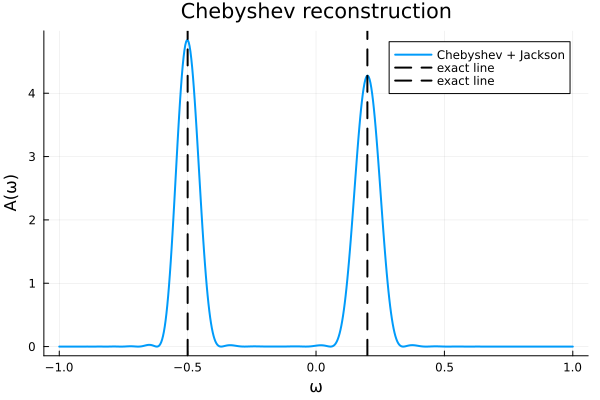

In [3]:
ω_grid = range(-halfwidth, halfwidth; length=600)
ρ_grid = spectrum(collect(ω_grid))

spectrum_plot = plot(
    ω_grid,
    ρ_grid;
    xlabel="ω",
    ylabel="A(ω)",
    title="Chebyshev reconstruction",
    label="Chebyshev + Jackson",
)

for energy in (energy_a, energy_b)
    vline!(spectrum_plot, [energy]; color=:black, linestyle=:dash, label="exact line")
end

spectrum_plot


## Moment structure

It is also useful to look directly at the moment sequence. For this simple two-line example, the moments are highly structured because they come from a short discrete spectral measure. In a more generic many-body problem, this plot becomes a quick diagnostic for whether the recursion is behaving smoothly and whether the chosen order is large enough to resolve the desired features.


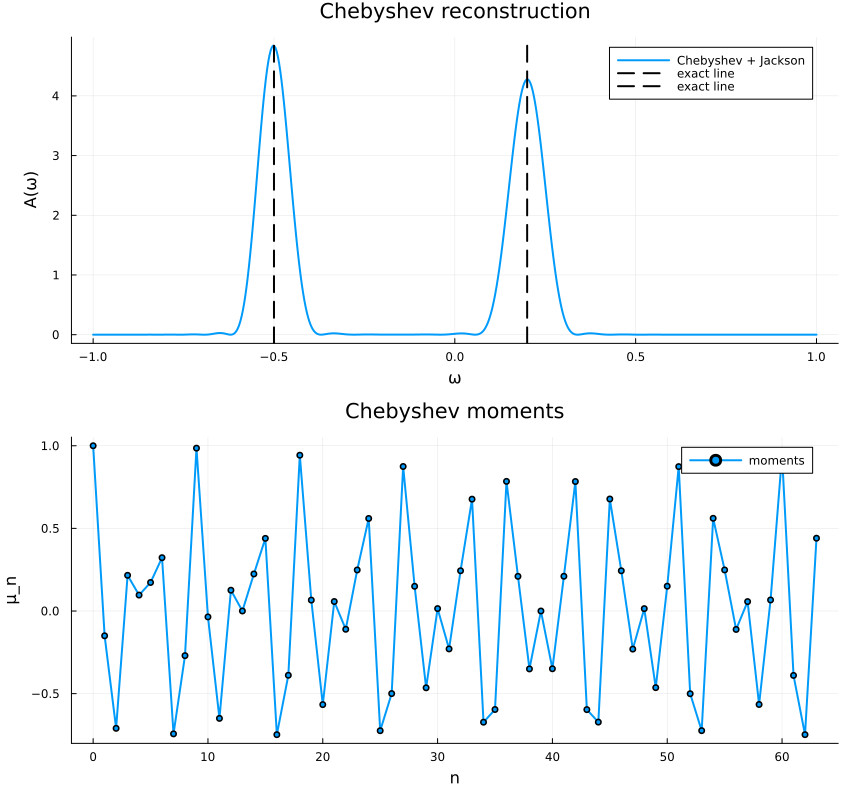

In [4]:
moment_plot = plot(
    0:(order - 1),
    moments;
    xlabel="n",
    ylabel="μ_n",
    marker=:circle,
    markersize=3,
    title="Chebyshev moments",
    label="moments",
)

plot(spectrum_plot, moment_plot; layout=(2, 1), size=(850, 800))
